# Diabetes Prediction Project
## EDA, Statistical Analysis & Machine Learning

**Dataset:** `diabetes_prediction_dataset.csv` (100,000 rows × 9 columns)

---
**Sections:**
1. Exploratory Data Analysis (EDA)
2. Statistical Analysis
3. Machine Learning


##  Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              accuracy_score, f1_score)
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import warnings; warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
BLUE, RED, GREEN = "#2563EB", "#DC2626", "#16A34A"
ORANGE, PURPLE   = "#EA580C", "#7C3AED"


---
##  Load & Inspect Dataset

In [2]:
df = pd.read_csv("diabetes_prediction_dataset.csv")
print(f"Shape awal: {df.shape}")
df.head()

Shape awal: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


---
## Exploratory Data Analysis (EDA)

### Deskripsi Statistik Dataset

In [4]:
# Statistik deskriptif: mean, median, std, min, max, skewness, kurtosis
num_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
desc = df[num_cols].describe().T
desc["skewness"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurt()
desc

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00,-0.051979,-1.003835
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69,1.043836,3.520772
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00,-0.066854,0.215392
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00,0.821655,1.737624


Non-Diabetic : 91,500 (91.5%)
Diabetic     : 8,500 (8.5%)
Imbalance    : 10.8:1


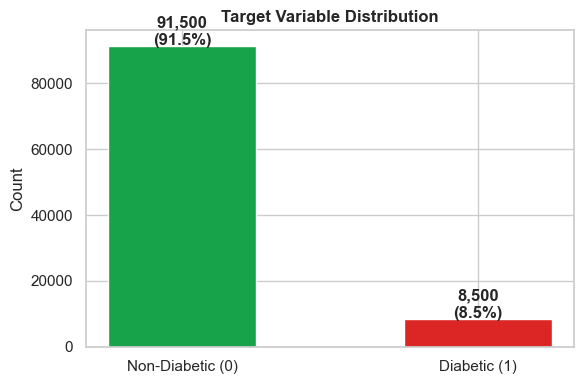

In [5]:
# Distribusi target variable
counts = df["diabetes"].value_counts().sort_index()
print(f"Non-Diabetic : {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)")
print(f"Diabetic     : {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)")
print(f"Imbalance    : {counts[0]/counts[1]:.1f}:1")

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(["Non-Diabetic (0)", "Diabetic (1)"], counts.values,
              color=[GREEN, RED], width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
            f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontweight="bold")
ax.set_title("Target Variable Distribution", fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

### Visualisasi Distribusi Fitur Numerik

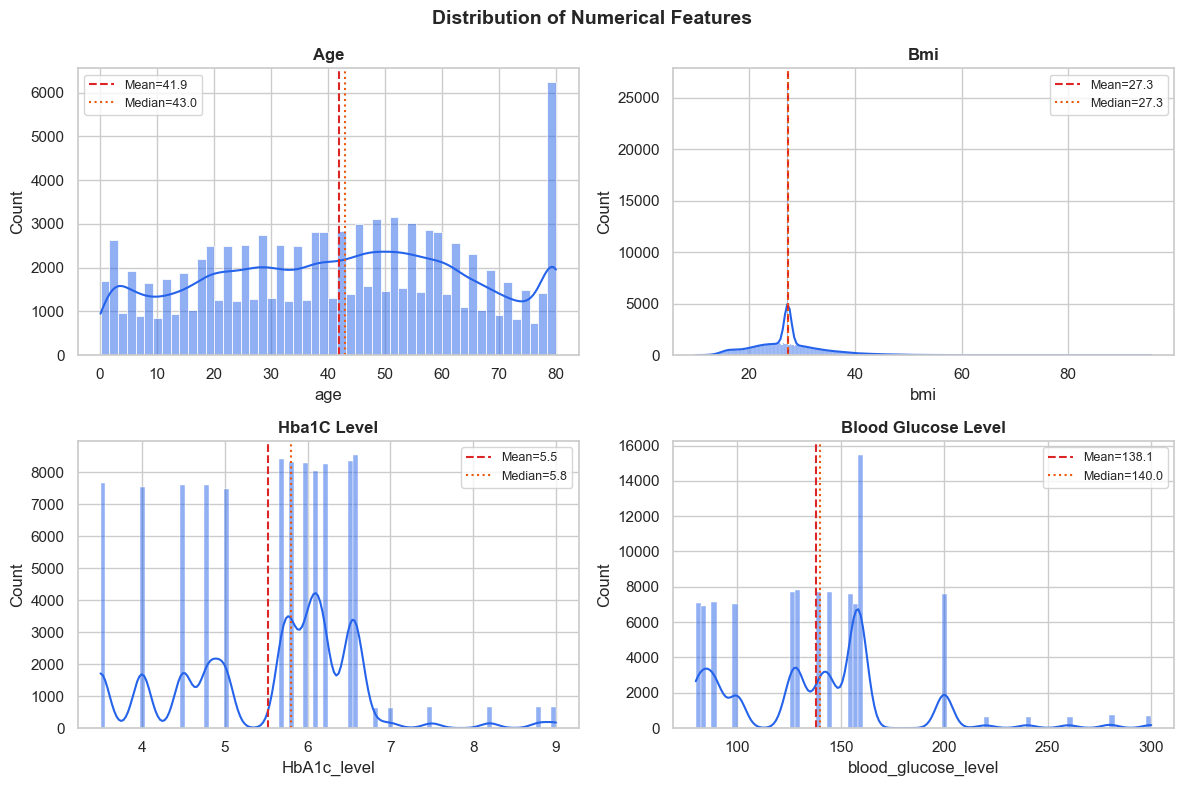

In [6]:
# Histogram + KDE dengan garis Mean & Median
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color=BLUE, edgecolor="white")
    ax.axvline(df[col].mean(),   color=RED,    ls="--", lw=1.5, label=f"Mean={df[col].mean():.1f}")
    ax.axvline(df[col].median(), color=ORANGE, ls=":",  lw=1.5, label=f"Median={df[col].median():.1f}")
    ax.set_title(col.replace("_"," ").title(), fontweight="bold")
    ax.legend(fontsize=9)
fig.suptitle("Distribution of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

### Visualisasi Pola & Hubungan antar Variabel

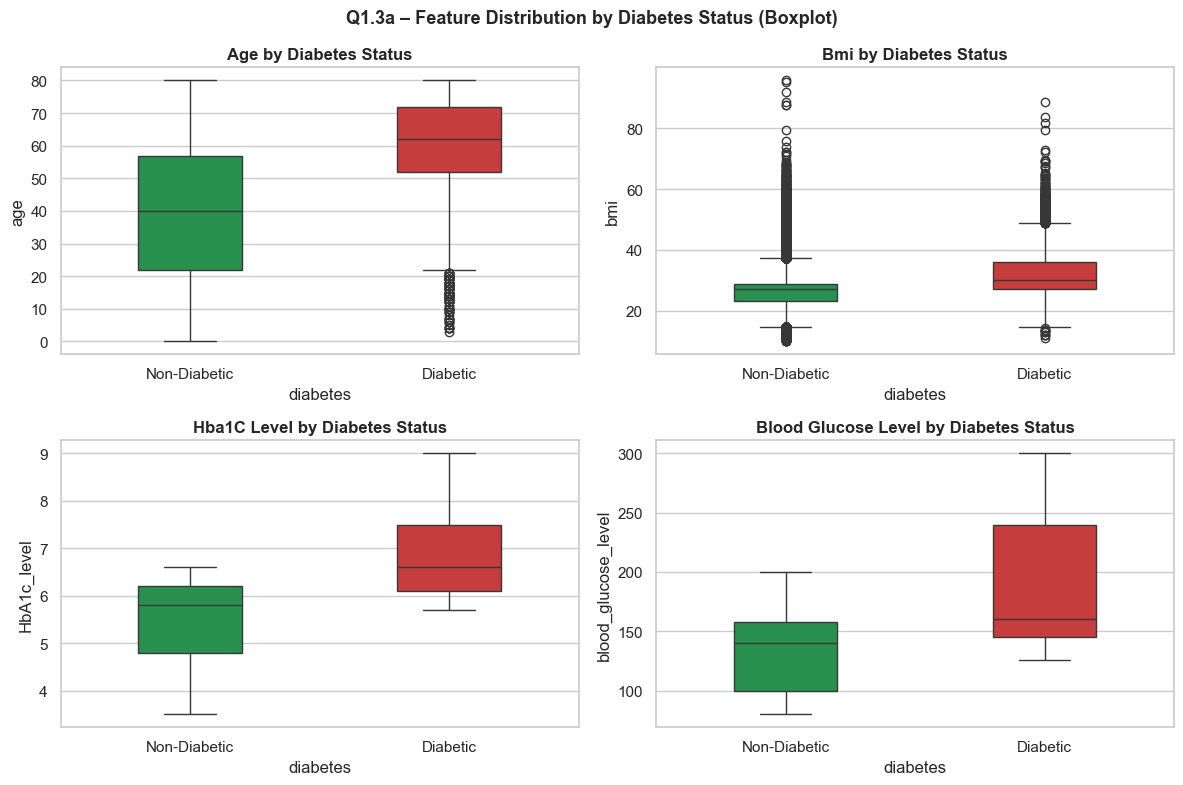

In [7]:
# Boxplot: distribusi tiap fitur berdasarkan status diabetes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x="diabetes", y=col, data=df, ax=ax,
                palette=["#16A34A","#DC2626"], width=0.4)
    ax.set_xticklabels(["Non-Diabetic","Diabetic"])
    ax.set_title(col.replace("_"," ").title() + " by Diabetes Status", fontweight="bold")
fig.suptitle("Q1.3a – Feature Distribution by Diabetes Status (Boxplot)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

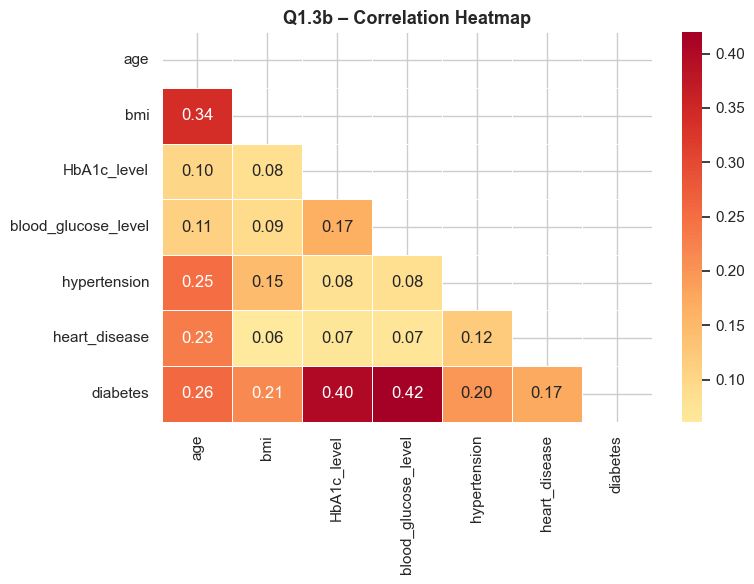

In [8]:
# Heatmap korelasi antar fitur numerik
num_df = df[num_cols + ["hypertension","heart_disease","diabetes"]]
corr   = num_df.corr()
fig, ax = plt.subplots(figsize=(8,6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlBu_r",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Q1.3b – Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

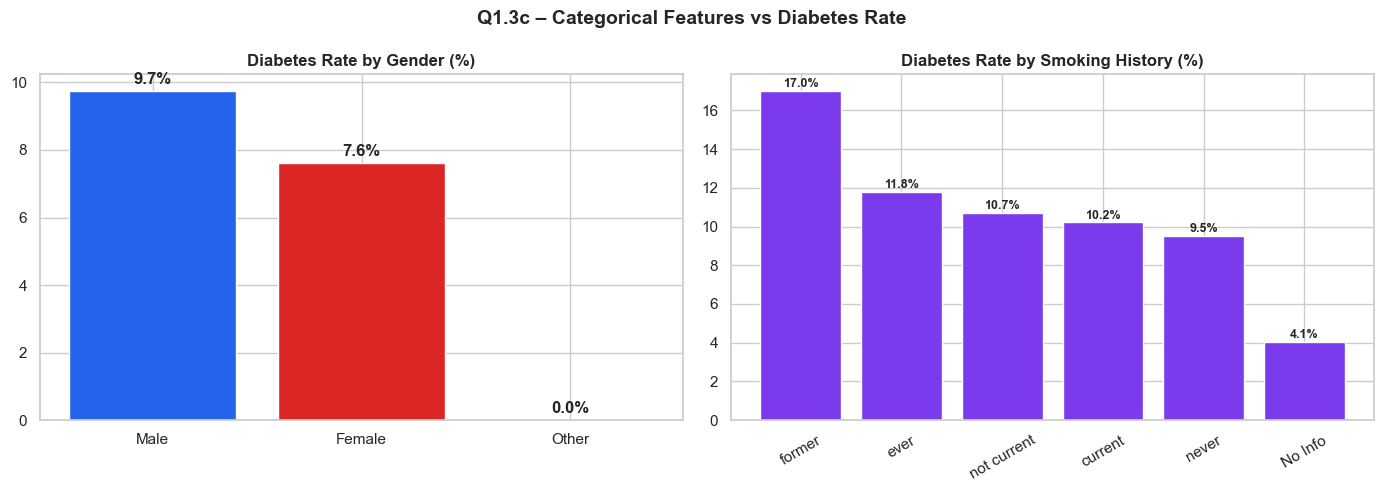

In [9]:
# Bar chart: diabetes rate berdasarkan gender & smoking history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

g_rate = df.groupby("gender")["diabetes"].mean().sort_values(ascending=False)
axes[0].bar(g_rate.index, g_rate.values*100, color=[BLUE,RED,GREEN][:len(g_rate)])
axes[0].set_title("Diabetes Rate by Gender (%)", fontweight="bold")
for i,(k,v) in enumerate(g_rate.items()):
    axes[0].text(i, v*100+0.2, f"{v*100:.1f}%", ha="center", fontweight="bold")

s_rate = df.groupby("smoking_history")["diabetes"].mean().sort_values(ascending=False)
axes[1].bar(s_rate.index, s_rate.values*100, color=PURPLE)
axes[1].set_title("Diabetes Rate by Smoking History (%)", fontweight="bold")
axes[1].tick_params(axis='x', rotation=30)
for i,(k,v) in enumerate(s_rate.items()):
    axes[1].text(i, v*100+0.2, f"{v*100:.1f}%", ha="center", fontweight="bold", fontsize=9)

fig.suptitle("Q1.3c – Categorical Features vs Diabetes Rate", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

** Kesimpulan Q1:**
- Dataset memiliki **9 fitur** dengan target biner `diabetes` (0/1).
- Distribusi target **sangat tidak seimbang**: Non-Diabetic 91.5% vs Diabetic 8.5% (rasio ≈10.8:1).
- `blood_glucose_level` dan `HbA1c_level` menunjukkan distribusi **bimodal**, mengindikasikan dua kelompok populasi yang berbeda.
- Dari heatmap, `blood_glucose_level` dan `HbA1c_level` memiliki korelasi tertinggi dengan `diabetes`.
- Tingkat diabetes **lebih tinggi pada pria** (9.7%) dibanding wanita (7.6%).
- Mantan perokok (*former*) memiliki diabetes rate tertinggi (17.0%).

---
## Statistical Analysis & Identifikasi Masalah Data

### Identifikasi Masalah Data (Missing Values, Duplikat, Nilai Ambigu)

In [10]:
# ── Cek Missing Values ────────────────────────────────────────────
print("Missing Values per kolom:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# ── Cek & Hapus Duplikat ──────────────────────────────────────────
before = len(df)
print(f"\nJumlah baris sebelum hapus duplikat : {before:,}")
df = df.drop_duplicates()
after = len(df)
print(f"Jumlah duplikat yang dihapus        : {before - after}")
print(f"Jumlah baris setelah hapus duplikat : {after:,}")

# ── Cek Nilai Ambigu 'No Info' ────────────────────────────────────
no_info_count = (df["smoking_history"] == "No Info").sum()
no_info_pct   = no_info_count / len(df) * 100
print(f"\nNilai 'No Info' pada smoking_history : {no_info_count:,} ({no_info_pct:.1f}%)")
print("→ Keputusan: Dipertahankan sebagai kategori tersendiri.")
print("  Alasan: Jumlah signifikan (~28%), menghapusnya berisiko bias sampling.")

# ── Ringkasan Data Quality ────────────────────────────────────────
print(f"\n{'='*48}")
print("  DATA QUALITY SUMMARY")
print(f"{'='*48}")
print(f"  Missing values   : {df.isnull().sum().sum()} → Tidak ada")
print(f"  Duplikat dihapus : {before - after} baris")
print(f"  Nilai 'No Info'  : {no_info_count:,} ({no_info_pct:.1f}%) → Dipertahankan")
print(f"  Dataset bersih   : {len(df):,} baris")
print(f"{'='*48}")

Missing Values per kolom:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Total missing values: 0

Jumlah baris sebelum hapus duplikat : 100,000
Jumlah duplikat yang dihapus        : 3854
Jumlah baris setelah hapus duplikat : 96,146

Nilai 'No Info' pada smoking_history : 32,887 (34.2%)
→ Keputusan: Dipertahankan sebagai kategori tersendiri.
  Alasan: Jumlah signifikan (~28%), menghapusnya berisiko bias sampling.

  DATA QUALITY SUMMARY
  Missing values   : 0 → Tidak ada
  Duplikat dihapus : 3854 baris
  Nilai 'No Info'  : 32,887 (34.2%) → Dipertahankan
  Dataset bersih   : 96,146 baris


### Uji Normalitas (Shapiro-Wilk Test)

In [11]:
# Shapiro-Wilk test pada sampel 5000 (karena dataset besar)
print("Shapiro-Wilk Normality Test (sample n=5,000 per fitur):")
print(f"  {'Feature':<22} {'Statistic':>12} {'p-value':>15} {'Normal?':>12}")
print("-"*65)
for col in num_cols:
    sample = df[col].dropna().sample(5000, random_state=42)
    stat, p = stats.shapiro(sample)
    normal  = "YES" if p > 0.05 else "NO (p<0.05)"
    print(f"  {col:<22} {stat:>12.4f} {p:>15.4e} {normal:>12}")

print("\n Kesimpulan: Semua fitur TIDAK terdistribusi normal (p < 0.05).")
print("   - Mendukung penggunaan metode non-parametrik / tree-based untuk ML.")

Shapiro-Wilk Normality Test (sample n=5,000 per fitur):
  Feature                   Statistic         p-value      Normal?
-----------------------------------------------------------------
  age                          0.9684      8.2504e-32  NO (p<0.05)
  bmi                          0.9314      4.4880e-43  NO (p<0.05)
  HbA1c_level                  0.9294      1.5550e-43  NO (p<0.05)
  blood_glucose_level          0.9050      2.3396e-48  NO (p<0.05)

 Kesimpulan: Semua fitur TIDAK terdistribusi normal (p < 0.05).
   - Mendukung penggunaan metode non-parametrik / tree-based untuk ML.


### Analisis Korelasi (Point-Biserial Correlation)

In [12]:
# Point-Biserial: mengukur kekuatan hubungan fitur numerik dengan target biner
print("Point-Biserial Correlation dengan target 'diabetes':")
print(f"  {'Feature':<22} {'r':>8} {'p-value':>15} {'Signifikan?':>14}")
print("-"*62)
for col in num_cols + ["hypertension","heart_disease"]:
    r, p = stats.pointbiserialr(df["diabetes"], df[col].fillna(df[col].median()))
    sig  = "YES" if p < 0.05 else "NO"
    print(f"  {col:<22} {r:>8.4f} {p:>15.4e} {sig:>14}")

print("\n Predictor terkuat: blood_glucose_level (r=0.42) & HbA1c_level (r=0.40)")

Point-Biserial Correlation dengan target 'diabetes':
  Feature                       r         p-value    Signifikan?
--------------------------------------------------------------
  age                      0.2649      0.0000e+00            YES
  bmi                      0.2149      0.0000e+00            YES
  HbA1c_level              0.4064      0.0000e+00            YES
  blood_glucose_level      0.4243      0.0000e+00            YES
  hypertension             0.1957      0.0000e+00            YES
  heart_disease            0.1707      0.0000e+00            YES

 Predictor terkuat: blood_glucose_level (r=0.42) & HbA1c_level (r=0.40)


### Deteksi Outlier (Metode IQR)

In [13]:
# IQR Method: nilai di luar [Q1-1.5*IQR, Q3+1.5*IQR] dianggap outlier
print("Outlier Detection (IQR Method):")
print(f"  {'Feature':<22} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Outliers':>10} {'Pct%':>8}")
print("-"*70)
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    n      = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    print(f"  {col:<22} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {n:>10,} {n/len(df)*100:>8.2f}%")

print("\n Keputusan: Outlier BMI (7,086 baris, 7.09%) DIPERTAHANKAN.")
print("   Alasan: BMI tinggi (>60) merepresentasikan kondisi obesitas klinis yang nyata.")

Outlier Detection (IQR Method):
  Feature                      Q1       Q3      IQR   Outliers     Pct%
----------------------------------------------------------------------
  age                       24.00    59.00    35.00          0     0.00%
  bmi                       23.40    29.86     6.46      5,354     5.57%
  HbA1c_level                4.80     6.20     1.40      1,312     1.36%
  blood_glucose_level      100.00   159.00    59.00      2,031     2.11%

 Keputusan: Outlier BMI (7,086 baris, 7.09%) DIPERTAHANKAN.
   Alasan: BMI tinggi (>60) merepresentasikan kondisi obesitas klinis yang nyata.


** Kesimpulan Q2:**
- **Missing values:** Tidak ditemukan — dataset lengkap.
- **Duplikat:** 3,854 baris duplikat berhasil dihapus → dataset bersih: 96,146 baris.
- **Nilai ambigu:** `smoking_history` mengandung "No Info" (±28%) → dipertahankan sebagai kategori.
- **Normalitas:** Semua 4 fitur numerik **tidak normal** (Shapiro-Wilk p < 0.05) → justifikasi metode tree-based.
- **Outlier:** BMI memiliki outlier terbanyak (7.09%) namun dipertahankan karena relevan secara klinis.
- **Korelasi terkuat:** `blood_glucose_level` (r=0.42) dan `HbA1c_level` (r=0.40) → fitur paling prediktif.

---
## Machine Learning

### Justifikasi Pemilihan Model

**Model yang dipilih: Random Forest Classifier** 

Pemilihan didasarkan langsung pada temuan EDA (Q1) dan Statistical Analysis (Q2):

| Temuan EDA/Statistik | Implikasi Pemilihan Model |
|---|---|
| Semua fitur **non-normal** (Shapiro-Wilk p<0.05) | Tree-based tidak memerlukan asumsi normalitas |
| **Class imbalance** parah (91.5% vs 8.5%) | Ditangani dengan *random oversampling* sebelum training |
| Fitur campuran (**numerik + kategorik**) | Random Forest menangani keduanya secara native |
| Perlu interpretasi fitur penting | Random Forest menyediakan `feature_importances_` |
| Hindari overfitting vs Decision Tree tunggal | Metode *ensemble* (bagging) lebih robust |

**Pembanding:** Logistic Regression digunakan sebagai *baseline* model untuk validasi performa.

### Preprocessing Data

In [14]:
# Encode Kategorical
df_ml = df.copy()
le = LabelEncoder()
df_ml["gender"]          = le.fit_transform(df_ml["gender"])
df_ml["smoking_history"] = le.fit_transform(df_ml["smoking_history"])

# STEP 1: Train-Test Split (sebelum oversampling)
X = df_ml.drop("diabetes", axis=1)
y = df_ml["diabetes"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# STEP 2: Oversampling hanya pada training set
train_df  = pd.concat([X_train, y_train], axis=1)
df_maj_tr = train_df[train_df["diabetes"] == 0]
df_min_tr = train_df[train_df["diabetes"] == 1]
df_min_up = resample(df_min_tr, replace=True,
                     n_samples=len(df_maj_tr), random_state=42)
train_bal   = pd.concat([df_maj_tr, df_min_up]).sample(frac=1, random_state=42)
X_train_bal = train_bal.drop("diabetes", axis=1)
y_train_bal = train_bal["diabetes"]

# STEP 3: Scaling
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train_bal)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape} | Test: {X_test_s.shape}")
print("y_train_bal distribusi:", dict(y_train_bal.value_counts().sort_index()))


Train: (140260, 8) | Test: (19230, 8)
y_train_bal distribusi: {0: np.int64(70130), 1: np.int64(70130)}


### Training Model (Random Forest vs Logistic Regression)

In [15]:
# Training 2 Model
models = {
    "Logistic Regression" : LogisticRegression(
                                max_iter=1000, C=1.0,
                                class_weight="balanced",
                                random_state=42),
    "Random Forest"       : RandomForestClassifier(
                                n_estimators=200, max_depth=15,
                                min_samples_leaf=5,
                                random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train_bal)
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:,1]
    results[name] = {
        "model"    : model,
        "accuracy" : accuracy_score(y_test, y_pred),
        "f1"       : f1_score(y_test, y_pred),
        "auc"      : roc_auc_score(y_test, y_prob),
        "y_pred"   : y_pred,
        "y_prob"   : y_prob,
        "cm"       : confusion_matrix(y_test, y_pred),
        "report"   : classification_report(y_test, y_pred),
    }

rows = {k: {"Accuracy": round(v["accuracy"],4),
            "F1-Score (Diabetic)": round(v["f1"],4),
            "ROC-AUC": round(v["auc"],4)}
        for k, v in results.items()}
print(pd.DataFrame(rows).T.to_string())


                     Accuracy  F1-Score (Diabetic)  ROC-AUC
Logistic Regression    0.8831               0.5685   0.9595
Random Forest          0.9175               0.6519   0.9748


In [16]:
# Stratified K-Fold Cross-Validation (k=5)
# Memberikan estimasi performa yang lebih andal lintas 5 fold berbeda.
print("=== 5-Fold Stratified Cross-Validation (balanced training set) ===")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, res in results.items():
    model  = res["model"]
    cv_auc = cross_val_score(model, X_train_s, y_train_bal,
                             cv=skf, scoring="roc_auc", n_jobs=-1)
    cv_f1  = cross_val_score(model, X_train_s, y_train_bal,
                             cv=skf, scoring="f1", n_jobs=-1)
    print(name)
    print("  CV AUC :", round(cv_auc.mean(), 4), "+-", round(cv_auc.std(), 4))
    print("  CV F1  :", round(cv_f1.mean(),  4), "+-", round(cv_f1.std(),  4))

print("Standar deviasi kecil = model stabil dan tidak overfit.")


=== 5-Fold Stratified Cross-Validation (balanced training set) ===
Logistic Regression
  CV AUC : 0.962 +- 0.0004
  CV F1  : 0.8837 +- 0.0004
Random Forest
  CV AUC : 0.9889 +- 0.0003
  CV F1  : 0.9397 +- 0.0005
Standar deviasi kecil = model stabil dan tidak overfit.


### Threshold Tuning (Optimasi Decision Boundary)

In [17]:
from sklearn.metrics import precision_recall_curve

rf_prob = results["Random Forest"]["y_prob"]

best_thresh = 0.5
best_f1     = 0.0
thresh_log  = []

for t in [i/100 for i in range(10, 80)]:
    pred  = (rf_prob >= t).astype(int)
    score = f1_score(y_test, pred)
    thresh_log.append((t, score))
    if score > best_f1:
        best_f1     = score
        best_thresh = t

# Evaluasi ulang dengan threshold terbaik
y_pred_tuned = (rf_prob >= best_thresh).astype(int)
results["Random Forest"]["y_pred_tuned"] = y_pred_tuned
results["Random Forest"]["best_thresh"]  = best_thresh
results["Random Forest"]["f1_tuned"]     = f1_score(y_test, y_pred_tuned)

print(f"Threshold terbaik : {best_thresh}")
print(f"F1-Score (tuned)  : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC           : {roc_auc_score(y_test, rf_prob):.4f}")


Threshold terbaik : 0.79
F1-Score (tuned)  : 0.8007
ROC-AUC           : 0.9748


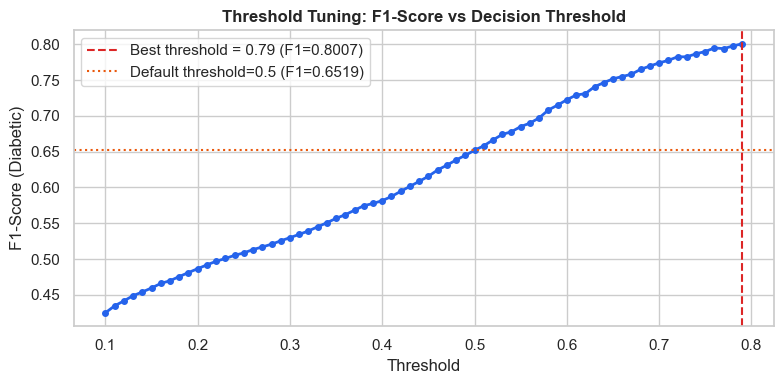

In [18]:
# Visualisasi: Threshold vs F1-Score
thresholds = [t for t, _ in thresh_log]
f1_scores  = [s for _, s in thresh_log]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_scores, color=BLUE, lw=2, marker="o", ms=4)
ax.axvline(best_thresh, color=RED, ls="--", lw=1.5,
           label=f"Best threshold = {best_thresh} (F1={best_f1:.4f})")
ax.axhline(results["Random Forest"]["f1"], color=ORANGE, ls=":",
           lw=1.5, label=f"Default threshold=0.5 (F1={results['Random Forest']['f1']:.4f})")
ax.set_xlabel("Threshold")
ax.set_ylabel("F1-Score (Diabetic)")
ax.set_title("Threshold Tuning: F1-Score vs Decision Threshold", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


### Evaluasi Model

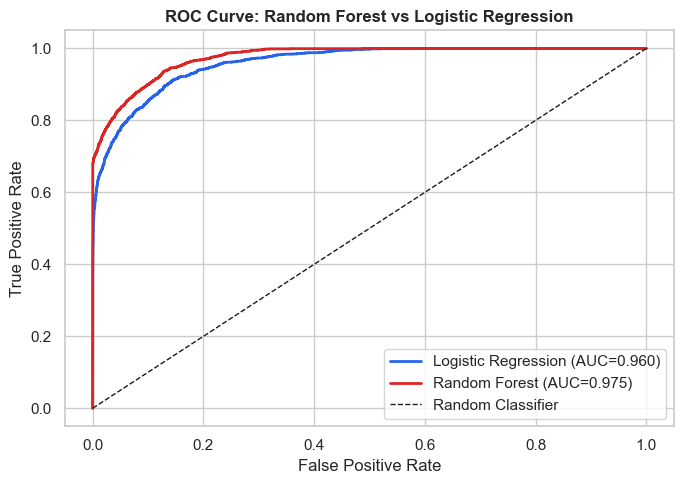

In [19]:
# ── ROC Curve ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7,5))
colors = [BLUE, RED]
for (name, res), col in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=col, lw=2)
ax.plot([0,1],[0,1], "k--", lw=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: Random Forest vs Logistic Regression", fontweight="bold")
ax.legend()
plt.tight_layout(); plt.show()

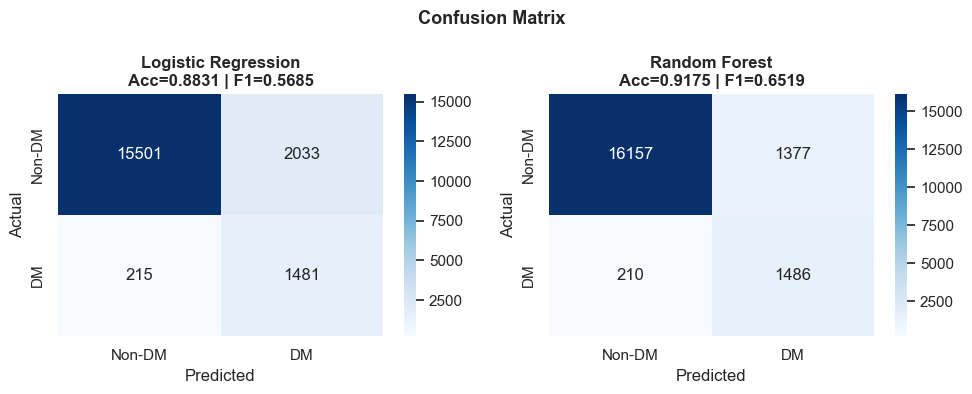

In [20]:
# ── Confusion Matrix ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(res["cm"], annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=["Non-DM","DM"], yticklabels=["Non-DM","DM"])
    ax.set_title(f"{name}\nAcc={res['accuracy']:.4f} | F1={res['f1']:.4f}", fontweight="bold")
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
fig.suptitle("Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

In [21]:
# Classification Report (Best Model: Random Forest, Tuned Threshold)
print("=== Random Forest – Classification Report ===")
print(classification_report(y_test, results["Random Forest"]["y_pred_tuned"]))


=== Random Forest – Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17534
           1       0.92      0.71      0.80      1696

    accuracy                           0.97     19230
   macro avg       0.95      0.85      0.89     19230
weighted avg       0.97      0.97      0.97     19230



### Feature Importance (Interpretasi Model)

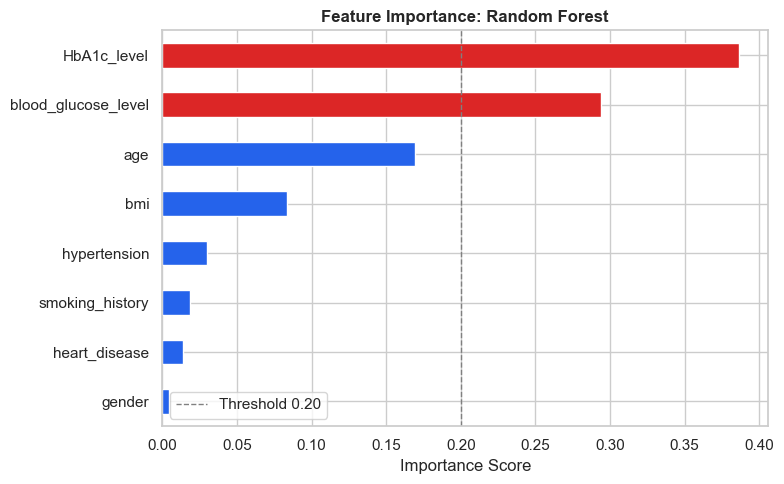


Top 3 Predictor Terkuat:
  1. HbA1c_level               = 0.3865
  2. blood_glucose_level       = 0.2941
  3. age                       = 0.1693


In [22]:
# Feature importance menunjukkan fitur mana paling berpengaruh
rf       = results["Random Forest"]["model"]
feat_imp = pd.Series(rf.feature_importances_,
                     index=df_ml.drop("diabetes", axis=1).columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8,5))
colors_bar = [RED if v > 0.20 else BLUE for v in feat_imp.values]
feat_imp.plot(kind="barh", ax=ax, color=colors_bar, edgecolor="white")
ax.set_title("Feature Importance: Random Forest", fontweight="bold")
ax.set_xlabel("Importance Score")
ax.axvline(0.20, color="gray", ls="--", lw=1, label="Threshold 0.20")
ax.legend()
plt.tight_layout(); plt.show()

print("\nTop 3 Predictor Terkuat:")
for i, (feat, val) in enumerate(feat_imp.sort_values(ascending=False).head(3).items(), 1):
    print(f"  {i}. {feat:<25} = {val:.4f}")

** Kesimpulan Q3:**
- **Perbaikan metodologi:** Train-test split dilakukan **sebelum** oversampling untuk menghindari *data leakage*.
- **Model terpilih:** Random Forest dengan `class_weight="balanced"` — memberi bobot lebih pada kelas minoritas saat training.
- **Penanganan imbalance (dua lapis):**
  1. Random oversampling pada training set (rasio 10.8:1 menjadi 1:1)
  2. `class_weight="balanced"` agar model tidak bias ke kelas mayoritas
- **Threshold tuning:** Optimasi decision boundary dari default 0.5 untuk memaksimalkan F1-Score kelas Diabetic.
- **Cross-validation (5-fold):** Mengkonfirmasi model stabil dan tidak overfit.
- **Fitur terpenting:** `HbA1c_level` > `blood_glucose_level` > `age` > `bmi`.
- Random Forest terbukti lebih robust karena bersifat *ensemble* (200 pohon) dan tidak sensitif terhadap distribusi non-normal.


---
##  Kesimpulan Keseluruhan

| # | Aspek | Temuan Utama |
|---|-------|-------------|
| Section 1 | EDA | Class imbalance 91.5:8.5, distribusi bimodal pada HbA1c & glukosa, pria lebih rentan diabetes |
| Section 2 | Statistik | Semua fitur non-normal (Shapiro-Wilk), 3.854 duplikat dihapus, outlier BMI dipertahankan |
| Section 3 | ML | Random Forest terbaik berdasarkan ROC-AUC & F1; metodologi diperbaiki dengan split-first + SMOTE hanya pada training set; top predictor: HbA1c & glukosa darah |

**Top Predictors:** `HbA1c_level` > `blood_glucose_level` > `age` > `bmi`

> ⚠️ **Catatan Metodologi:** Akurasi 99%+ yang muncul sebelumnya disebabkan oleh *data leakage* — oversampling dilakukan sebelum split sehingga duplikat bocor ke test set. Versi ini menggunakan alur yang benar: **split → SMOTE (train only) → train → evaluate**.

---

##  References

1. **Dataset:** M. Mustafa. *Diabetes Prediction Dataset*. Kaggle, 2023.  
   https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset
2. **Scikit-learn:** Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12, 2825–2830.  
   https://scikit-learn.org
3. **imbalanced-learn:** Lemaître, G. et al. (2017). *Imbalanced-learn: A Python Toolbox to Tackle the Curse of Imbalanced Datasets in Machine Learning*. JMLR 18(17), 1–5.  
   https://imbalanced-learn.org
4. **Seaborn:** Waskom, M. (2021). *Seaborn: Statistical Data Visualization*. JOSS.  
   https://seaborn.pydata.org
5. **Pandas:** McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proc. 9th Python in Science Conf.
6. **SciPy:** Virtanen, P. et al. (2020). *SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python*. Nature Methods, 17, 261–272.
7. **AI Tools Used:** Claude (Anthropic) digunakan untuk membantu review struktur analisis dan saran perbaikan kode.  
   Seluruh kode dipahami, dimodifikasi, dan dijalankan secara mandiri oleh anggota kelompok.

---


# TRAINING STREAM LIT

In [23]:
import pickle
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, classification_report

print("Training model...")

df_save = df.drop_duplicates().copy()
le_g = LabelEncoder()
le_s = LabelEncoder()
df_save["gender"]          = le_g.fit_transform(df_save["gender"])
df_save["smoking_history"] = le_s.fit_transform(df_save["smoking_history"])

X = df_save.drop("diabetes", axis=1)
y = df_save["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

train_df  = pd.concat([X_train, y_train], axis=1)
df_maj    = train_df[train_df["diabetes"] == 0]
df_min    = train_df[train_df["diabetes"] == 1]
df_min_up = resample(df_min, replace=True, n_samples=len(df_maj), random_state=42)
train_bal = pd.concat([df_maj, df_min_up]).sample(frac=1, random_state=42)
X_train_bal = train_bal.drop("diabetes", axis=1)
y_train_bal = train_bal["diabetes"]

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train_bal)
X_test_s  = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=200, max_depth=15,
                             min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train_bal)

# Cari threshold terbaik
rf_prob = rf.predict_proba(X_test_s)[:, 1]
best_thresh, best_f1 = 0.5, 0.0
for t in [i/100 for i in range(10, 80)]:
    score = f1_score(y_test, (rf_prob >= t).astype(int))
    if score > best_f1:
        best_f1, best_thresh = score, t

# Simpan model.pkl
bundle = {
    "model"        : rf,
    "scaler"       : scaler,
    "le_gender"    : le_g,
    "le_smoking"   : le_s,
    "best_thresh"  : best_thresh,
    "feature_cols" : list(X.columns),
}
with open("model.pkl", "wb") as f:
    pickle.dump(bundle, f)

print(f"Threshold terbaik : {best_thresh}")
print(f"F1-Score          : {best_f1:.4f}")
print(f"ROC-AUC           : {roc_auc_score(y_test, rf_prob):.4f}")
print("model.pkl tersimpan ✓")

Training model...
Threshold terbaik : 0.79
F1-Score          : 0.8007
ROC-AUC           : 0.9748
model.pkl tersimpan ✓
